In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [38]:
df = pd.read_csv("data/audio_features_output_v3.csv")
meta_df = pd.read_csv("data/pilot_v2.csv")

In [39]:
df = df.merge(meta_df[["clue_id", "Spymaster ID"]], on="clue_id", how="left")
df.head()

,clue_id,confidence,difficulty,transcript,clue_word_frequency,duration,clue_latency,clue_number_latency,speech_rate,speech_ratio,...,mfcc_13_std,energy_mean,energy_std,energy_range,energy_p25,energy_p75,jitter,shimmer,hnr,Spymaster ID
0,1,3,2,"Okay, let me see here. So, mm-hmm. Alright, t...",5.08,27.456,24.82,0.00,0.728438,0.515734,...,6.227731,0.044402,0.089154,0.545529,0.000000,0.049380,0.020543,0.121808,15.683529,2
1,2,4,1,homo sapiens to,1.59,7.776,5.22,0.56,0.385802,0.297068,...,5.775799,0.039343,0.090567,0.383022,0.000000,0.009860,0.029517,0.145391,11.074242,2
2,3,4,2,Amendment Now.,5.35,0.928,0.00,0.00,2.155172,0.678879,...,5.754251,0.073053,0.060342,0.162253,0.000000,0.127136,0.025945,0.112453,14.221208,2
3,4,2,4,"This is tough here. Scalpi sensor, 2.",3.92,16.256,15.56,0.94,0.430610,0.322958,...,3.518966,0.040156,0.089109,0.477367,0.000000,0.012117,0.033573,0.140501,9.131941,2
4,5,4,3,"See, I don't know how to link some of these. ...",3.91,32.832,3.14,0.22,0.974659,0.926535,...,6.323685,0.050550,0.086104,0.450530,0.005841,0.040372,0.025149,0.102263,14.127368,2


In [40]:
len(df)

50

## 1. Speaker Level Normalization

In [41]:
EXCLUDE = ["clue_id", "confidence", "difficulty", "transcript", "Spymaster ID"]
FEATURE_COLS = [c for c in df.columns if c not in EXCLUDE]
df[FEATURE_COLS] = df[FEATURE_COLS].astype(float)

In [42]:
df_norm = df.copy()

for speaker, group in df.groupby("Spymaster ID"):
    idx = group.index

    mean = group[FEATURE_COLS].mean()
    std = group[FEATURE_COLS].std().replace(0, 1)

    df_norm.loc[idx, FEATURE_COLS] = (group[FEATURE_COLS] - mean) / std

In [43]:
# sanity check 1: values should be close to 1
# df_norm.groupby("Spymaster ID")[FEATURE_COLS].std().round(2)

In [44]:
# sanity check 1: values should be close to 0
# df_norm.groupby("Spymaster ID")[FEATURE_COLS].mean().round(2)

## 2. Correlation Analysis

In [45]:
corr = df_norm[FEATURE_COLS].corr()

In [46]:
# find highly correlated pairs
threshold = 0.9

high_corr_pairs = []

for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i, j]) > threshold:
            col1 = corr.columns[i]
            col2 = corr.columns[j]
            high_corr_pairs.append((col1, col2, corr.iloc[i, j]))

high_corr_pairs[:10]

[('mfcc_2_mean', 'mfcc_1_mean', np.float64(0.9181896276508067)),
 ('mfcc_4_mean', 'mfcc_2_mean', np.float64(0.9194359584420306)),
 ('mfcc_4_mean', 'mfcc_3_mean', np.float64(0.96034578289333)),
 ('mfcc_6_mean', 'mfcc_5_mean', np.float64(0.9402913616743496)),
 ('mfcc_7_std', 'mfcc_6_std', np.float64(0.9295244258972848)),
 ('mfcc_8_std', 'mfcc_7_std', np.float64(0.9169967771568731)),
 ('mfcc_11_std', 'mfcc_8_std', np.float64(0.912633355624876)),
 ('mfcc_13_std', 'mfcc_12_std', np.float64(0.9455295157198886)),
 ('energy_std', 'energy_mean', np.float64(-0.9229440494557961)),
 ('energy_p25', 'mfcc_4_mean', np.float64(0.9185043262936822))]

**Observations**: 

Pause count and duration are highly correlated, which makes sense: longer audio = more pauses --> drop pause_count 

MFCC features seem to be highly correlated too, but they are inherently correlated, and they represent a joint spectral space. Let's keep them for now, some models like RF and boosting handle them well. 

In [47]:
FEATURE_COLS_REDUCED = [c for c in FEATURE_COLS if c != "pause_count"]

## 3. Distribution Checks (outliers + skew)

In [48]:
# check skewness
df_norm[FEATURE_COLS_REDUCED].skew().sort_values(ascending=False).head(15)

repetition_count           2.976113
filler_count               1.665939
pause_mid_speech           1.650176
pause_max                  1.328466
energy_p75                 1.314065
articulation_rate          1.152951
verbal_hesitation_count    1.128386
pitch_slope                1.039321
clue_number_latency        1.032775
pitch_p75                  1.015171
pause_mean                 0.978336
clue_latency               0.956520
duration                   0.910877
speech_rate                0.894576
meta_comment_presence      0.886617
dtype: float64

In [49]:
# check extreme values
df_norm[FEATURE_COLS_REDUCED].describe().T

,count,mean,std,min,25%,50%,75%,max
clue_word_frequency,50.0,2.087219e-16,0.958315,-2.370694,-0.635219,0.017604,0.680875,2.698626
duration,50.0,4.996004e-18,0.958315,-1.413474,-0.755257,-0.196041,0.588327,2.685255
clue_latency,50.0,-1.088019e-16,0.958315,-1.264717,-0.713027,-0.305827,0.456251,2.392310
clue_number_latency,50.0,-1.776357e-17,0.958315,-2.181797,-0.740251,-0.225860,0.206548,2.627646
speech_rate,50.0,-1.776357e-17,0.958315,-1.603888,-0.715245,-0.182440,0.593525,2.376291
speech_ratio,50.0,-9.769963e-17,0.958315,-1.302864,-0.842443,-0.226046,0.978197,1.546202
articulation_rate,50.0,-9.159340e-18,0.958315,-1.420549,-0.585835,-0.154821,0.208119,3.108567
pause_mean,50.0,-5.107026e-17,0.958315,-1.487240,-0.726184,-0.280846,0.652415,2.630370
pause_max,50.0,4.496403e-17,0.958315,-1.013388,-0.629820,-0.420467,0.238903,2.419722
pause_before_clue,50.0,3.552714e-17,0.958315,-1.054093,-0.677003,-0.428174,0.843274,2.140872


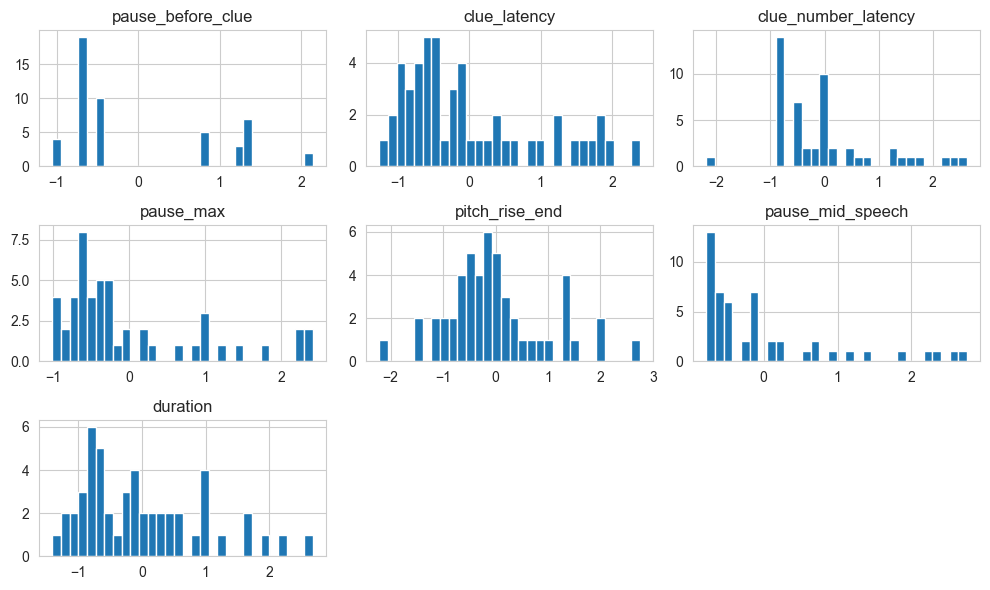

In [50]:
# visualize skewness of most skewed features
skewed_cols = ["pause_before_clue", "clue_latency", "clue_number_latency", "pause_max", "pitch_rise_end", "pause_mid_speech", "duration"]
df_norm[skewed_cols].hist(bins=30, figsize=(10, 6))
plt.tight_layout()
plt.show()

In [51]:
# apply log transform to stabilize variance
for col in skewed_cols:
    df_norm[col] = np.log1p(df_norm[col].clip(lower=0))

In [52]:
df_norm[skewed_cols].skew()

pause_before_clue      0.888812
clue_latency           1.334171
clue_number_latency    1.714586
pause_max              1.522054
pitch_rise_end         1.536408
pause_mid_speech       1.812284
duration               1.390867
dtype: float64

## 4. Collapse labels into 3 classes

In [53]:
# Define mapping: 1-2 → Non-confident, 3 → Neutral, 4-5 → Confident
def collapse_confidence(label):
    if label in [1, 2]:
        return "Non-confident"
    elif label == 3:
        return "Neutral"
    elif label in [4, 5]:
        return "Confident"
    else:
        return np.nan  # just in case

def collapse_difficulty(label):
    if label in [1, 2]:
        return "Easy"
    elif label == 3:
        return "Neutral"
    elif label in [4, 5]:
        return "Difficult"
    else:
        return np.nan  # just in case

df_norm['confidence_3class'] = df_norm['confidence'].apply(collapse_confidence)
df_norm['difficulty_3class'] = df_norm['difficulty'].apply(collapse_difficulty)

In [54]:
df_norm['confidence_3class'].value_counts()

confidence_3class
Confident        25
Neutral          13
Non-confident    12
Name: count, dtype: int64

In [55]:
df_norm['difficulty_3class'].value_counts()

difficulty_3class
Easy         26
Difficult    15
Neutral       9
Name: count, dtype: int64

In [56]:
df_norm.columns

Index(['clue_id', 'confidence', 'difficulty', 'transcript',
       'clue_word_frequency', 'duration', 'clue_latency',
       'clue_number_latency', 'speech_rate', 'speech_ratio',
       'articulation_rate', 'pause_count', 'pause_mean', 'pause_max',
       'pause_before_clue', 'pause_mid_speech', 'filler_count',
       'repetition_count', 'disfluency', 'verbal_hesitation_count',
       'meta_comment_presence', 'pitch_mean', 'pitch_std', 'pitch_slope',
       'pitch_rise_end', 'pitch_range', 'pitch_p25', 'pitch_p75',
       'mfcc_1_mean', 'mfcc_1_std', 'mfcc_2_mean', 'mfcc_2_std', 'mfcc_3_mean',
       'mfcc_3_std', 'mfcc_4_mean', 'mfcc_4_std', 'mfcc_5_mean', 'mfcc_5_std',
       'mfcc_6_mean', 'mfcc_6_std', 'mfcc_7_mean', 'mfcc_7_std', 'mfcc_8_mean',
       'mfcc_8_std', 'mfcc_9_mean', 'mfcc_9_std', 'mfcc_10_mean',
       'mfcc_10_std', 'mfcc_11_mean', 'mfcc_11_std', 'mfcc_12_mean',
       'mfcc_12_std', 'mfcc_13_mean', 'mfcc_13_std', 'energy_mean',
       'energy_std', 'energy_range', 

In [57]:
df_norm = df_norm.drop(columns=["Spymaster ID", "confidence", "difficulty"])
df_norm = df_norm.rename(columns={
    'confidence_3class': 'confidence',
    'difficulty_3class': 'difficulty'
})
df_norm.to_csv('data/clean_audio_data.csv', index=False)